In [28]:
import os.path
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import os, time, json, math
from typing import List, Any, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from fasterrisk.fasterrisk import RiskScoreOptimizer, RiskScoreClassifier

## Config

In [29]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'sct_found_after_comp', 'sct_perp_dia'] #, 'sct_ab_gwth']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 58, 61, 64, 67],
    "sct_long_dia": [6, 8, 10, 15, 20, 30],
    "sct_perp_dia": [5, 10, 15, 20],
    # "sct_ab_gwth": [2]
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex', 'sct_found_after_comp']

# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

OUTDIR = "./image/fasterrisk3/"
os.makedirs(OUTDIR, exist_ok=True)

# Save CUTS_CONT to JSON for reference
cuts_cont_path = os.path.join(OUTDIR, "CUTS_CONT.json")
with open(cuts_cont_path, "w", encoding="utf-8") as f:
    json.dump(CUTS_CONT, f, ensure_ascii=False, indent=2)
print(f"[config] Saved CUTS_CONT to {cuts_cont_path}")

[config] Saved CUTS_CONT to ./image/fasterrisk3/CUTS_CONT.json


## Helpers to clean data

In [30]:
def filter_age_le_70(df):
    return df[df['age'] <= 70]

def _norm_text(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    s = s.replace('_','-').replace('–','-').replace('—','-')
    return s

def normalize_and_encode(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Canonicalize gender to {'male','female'}
    - Canonicalize Nodule_Type to {'solid','ground-glass','part-solid'} using common aliases
    - Create binaries: sex, part_solid, ground_glass, solid
    - Coerce Upper_Lobe/Spiculation to ints if present
    - Drop rows with unmapped gender/Nodule_Type; warn on non-exclusive types
    """
    df = df.copy()

    # gender
    g = df['gender'].apply(_norm_text)
    df['gender'] = g.map({'male':'male','m':'male','female':'female','f':'female'})

    # nodule type
    t = df['Nodule_Type'].apply(_norm_text)
    mapping = {
        'solid':'solid', 'sld':'solid',

        'ground-glass':'ground-glass', 'ground glass':'ground-glass',
        'ggo':'ground-glass', 'non-solid':'ground-glass',
        'non solid':'ground-glass', 'nonsolid':'ground-glass',

        'part-solid':'part-solid', 'part solid':'part-solid',
        'semi-solid':'part-solid', 'semisolid':'part-solid', 'subsolid':'part-solid',
    }
    df['Nodule_Type'] = t.map(mapping)

    # drop unmapped
    bad = df['gender'].isna() | df['Nodule_Type'].isna()
    if bad.any():
        print(f"[filter] Dropping {int(bad.sum())} rows with unmapped gender or Nodule_Type")
        # Uncomment to inspect:
        # print(df.loc[bad, [ID_COL,'gender','Nodule_Type']].head(10))
        df = df.loc[~bad].copy()

    # binaries
    df['sex']          = df['gender'].map({'male':0, 'female':1}).astype(int)
    df['part_solid']   = (df['Nodule_Type'] == 'part-solid').astype(int)
    df['ground_glass'] = (df['Nodule_Type'] == 'ground-glass').astype(int)
    df['solid']        = (df['Nodule_Type'] == 'solid').astype(int)

    # passthrough ints
    for b in ['Upper_Lobe','Spiculation']:
        if b in df.columns:
            df[b] = pd.to_numeric(df[b], errors='ignore')
            df[b] = pd.to_numeric(df[b], errors='coerce').fillna(0).astype(int)

    # sanity: exactly one nodule type flag
    onehot_sum = df[['solid','ground_glass','part_solid']].sum(axis=1)
    if (onehot_sum != 1).any():
        print(f"[warn] {int((onehot_sum != 1).sum())} rows have non-exclusive nodule types; please inspect.")

    return df

def to_fastrisk_y(y_raw, pos_label=1) -> np.ndarray:
    """Return 1-D np.ndarray[float] with labels in {-1.0, +1.0}."""
    y_arr = np.asarray(y_raw).ravel()
    uniq = set(np.unique(y_arr))
    if uniq <= {0, 1}:
        return (2 * y_arr - 1).astype(float)
    return np.where(y_arr == pos_label, 1.0, -1.0).astype(float)

def make_ge_bins(df: pd.DataFrame, feature: str, cuts: list[float]) -> pd.DataFrame:
    """
    Build binary features like 'age >= 73' or 'sct_long_dia >= 20' (ASCII >=)
    """
    out = pd.DataFrame(index=df.index)
    vals = pd.to_numeric(df[feature], errors='coerce')
    for c in cuts:
        col = f"{feature} >= {c:g}"
        out[col] = (vals >= float(c)).astype(int)
    return out

def build_binary_matrix(X_df: pd.DataFrame,
                        feature_cuts: dict[str, list[float]],
                        passthrough_binary: list[str]) -> pd.DataFrame:
    """Construct binary feature matrix for FasterRisk from raw DataFrame"""
    mats = []
    for feat, cuts in feature_cuts.items():
        if feat not in X_df.columns:
            raise KeyError(f"Missing feature for binning: {feat}")
        mats.append(make_ge_bins(X_df, feat, cuts))
    for feat in passthrough_binary:
        if feat not in X_df.columns:
            raise KeyError(f"Missing binary feature: {feat}")
        col = pd.Series(pd.to_numeric(X_df[feat], errors='coerce')).fillna(0).astype(int)
        mats.append(pd.DataFrame({feat: col}, index=X_df.index))
    return pd.concat(mats, axis=1)

def binarize_and_align_custom(X_train_df: pd.DataFrame,
                              X_val_df: pd.DataFrame,
                              X_test_df: pd.DataFrame,
                              feature_cuts: dict[str, list[float]],
                              passthrough_binary: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Binarize each split with ≥ cuts, then align val/test to training columns.
    """
    X_train_bin = build_binary_matrix(X_train_df, feature_cuts, passthrough_binary)
    X_val_bin   = build_binary_matrix(X_val_df,   feature_cuts, passthrough_binary)
    X_test_bin  = build_binary_matrix(X_test_df,  feature_cuts, passthrough_binary)

    def _align_like_train(train_bin_df: pd.DataFrame, other_bin_df: pd.DataFrame) -> pd.DataFrame:
        cols = list(train_bin_df.columns)
        return other_bin_df.reindex(columns=cols, fill_value=0)

    X_val_bin  = _align_like_train(X_train_bin, X_val_bin)
    X_test_bin = _align_like_train(X_train_bin, X_test_bin)

    # sanity
    assert list(X_val_bin.columns)  == list(X_train_bin.columns)
    assert list(X_test_bin.columns) == list(X_train_bin.columns)
    return X_train_bin, X_val_bin, X_test_bin

def prepare_data(df: pd.DataFrame, feature_cols: list[str], label_col: str):
    X = df[feature_cols]
    y = df[label_col]
    return X, y

## Preprocessing

In [31]:
# -------------------------
# Load, normalize/encode
# -------------------------
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

df1['sct_ab_gwth'] = df1['sct_ab_gwth'].fillna(0)
df2['sct_ab_gwth'] = df2['sct_ab_gwth'].fillna(0)

df1 = df1.dropna(subset=['sct_perp_dia'])
df2 = df2.dropna(subset=['sct_perp_dia'])

# -------------------------
# Patient-level stratified split (on df1)
# -------------------------
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

# ============================================================
# STLMD (includes age & sex)  —  bins: age >= c, sct_long_dia >= c, sct_perp_dia >= c, sct_ab_gwth >= c
# ============================================================
X_train_STLMD_df, y_train_STLMD_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)
X_val_STLMD_df,   y_val_STLMD_raw   = prepare_data(val_df,   FEATURES_STLMD, LABEL_COL)
X_test_STLMD_df,  y_test_STLMD_raw  = prepare_data(df2,      FEATURES_STLMD, LABEL_COL)

X_train_STLMD_bin, X_val_STLMD_bin, X_test_STLMD_bin = binarize_and_align_custom(
    X_train_STLMD_df, X_val_STLMD_df, X_test_STLMD_df,
    feature_cuts={"age": CUTS_CONT["age"], "sct_long_dia": CUTS_CONT["sct_long_dia"], "sct_perp_dia": CUTS_CONT["sct_perp_dia"]}, # , "sct_ab_gwth": CUTS_CONT["sct_ab_gwth"]
    passthrough_binary=BIN_PASSTHROUGH_STLMD
)

y_train_STLMD = to_fastrisk_y(y_train_STLMD_raw, pos_label=1)
y_val_STLMD   = to_fastrisk_y(y_val_STLMD_raw,   pos_label=1)
y_test_STLMD  = to_fastrisk_y(y_test_STLMD_raw,  pos_label=1)

X_train_STLMD = X_train_STLMD_bin.to_numpy(dtype=float)
X_val_STLMD   = X_val_STLMD_bin.to_numpy(dtype=float)
X_test_STLMD  = X_test_STLMD_bin.to_numpy(dtype=float)

# 将标签转换为 {0, 1} 格式（RandomForest 需要）
y_train_STLMD_01 = (y_train_STLMD + 1.0) / 2.0
y_test_STLMD_01 = (y_test_STLMD + 1.0) / 2.0

# -------------------------
# Quick hygiene checks
# -------------------------
def _chk(Xtr, ytr, Xv, yv, Xte, yte, name):
    assert Xtr.shape[0] == ytr.shape[0] and Xv.shape[0] == yv.shape[0] and Xte.shape[0] == yte.shape[0], f"row mismatch in {name}"
    assert set(np.unique(ytr)) <= {-1.0, 1.0} and set(np.unique(yv)) <= {-1.0, 1.0} and set(np.unique(yte)) <= {-1.0, 1.0}, f"bad labels in {name}"
    print(f"{name:7s} -> X_train {Xtr.shape}, X_val {Xv.shape}, X_test {Xte.shape}")

_chk(X_train_STLMD, y_train_STLMD, X_val_STLMD, y_val_STLMD, X_test_STLMD, y_test_STLMD, "STLMD")

# Optional: feature names for each design
FEATURE_NAMES_STLMD  = list(X_train_STLMD_bin.columns)

STLMD   -> X_train (24311, 22), X_val (6111, 22), X_test (28708, 22)


## Config for training

In [32]:
# ---- knobs you can tune ----
SPARSITY_K        = 5
PARENT_SIZE       = 50

# Rashomon / diversity knobs (documented in FasterRisk)
GAP_TOLERANCE     = 0.15   # larger -> accept more near-optimal models
SELECT_TOP_M      = 100    # keep more diverse supports
MAX_ATTEMPTS      = 200    # try more swaps/diversification

# choose which designs to run
DESIGNS_TO_RUN = ["STLMD"]   # e.g. ["STLMD","STLM","STPGLM"]

# ROC subplot grid (50 per page)
SUBPLOT_ROWS = 10
SUBPLOT_COLS = 5

## Helpers for training

In [33]:
# ---------------------------------------------
# Version-robust optimizer creation
# ---------------------------------------------
def make_optimizer(X, y,
                   k=SPARSITY_K, parent_size=PARENT_SIZE,
                   gap_tolerance=GAP_TOLERANCE,
                   select_top_m=SELECT_TOP_M,
                   max_attempts=MAX_ATTEMPTS,
                   want_intercept=True):
    
    # (1) gap + select_top_m + maxAttempts (camelCase)
   
        return RiskScoreOptimizer(
            X=X, y=y, k=k, parent_size=parent_size,
            gap_tolerance=gap_tolerance,
            select_top_m=select_top_m,
            maxAttempts=max_attempts)


# ---------------------------------------------
# extract models as (multipliers, beta0_int, betas_int)
# ---------------------------------------------
def extract_models(ret):
    if isinstance(ret, tuple) and len(ret) == 2:
        multipliers, integer_mat = ret
        integer_mat = np.asarray(integer_mat, dtype=int)
        beta0_int = integer_mat[:, 0]
        betas_int = integer_mat[:, 1:]
        return np.asarray(multipliers, float), beta0_int, betas_int
    elif isinstance(ret, tuple) and len(ret) == 3:
        multipliers, beta0_int, betas_int = ret
        return (np.asarray(multipliers, float),
                np.asarray(beta0_int, int),
                np.asarray(betas_int, int))
    else:
        raise RuntimeError("Unexpected return format from get_models()")


# ---------------------------------------------
# compute predicted probabilities of a single model and single data point
# ---------------------------------------------
def model_probs(mult: float, b0: float, betas: np.ndarray, X: np.ndarray) -> np.ndarray:
    z = b0 + X @ betas.astype(float)
    return 1.0 / (1.0 + np.exp(-z/mult))


# ---------------------------------------------
# Use entire test set to calculate AUC, accuracy, and predicted prob list
# ---------------------------------------------
def compute_model_metrics(multipliers, intercepts, coef_matrix, X, y):
    aucs, accs, n_terms, probs_list = [], [], [], []
    y01 = ((y + 1.0) / 2.0)  # {-1,+1} -> {0,1}
    for m, b0, w in zip(multipliers, intercepts, coef_matrix):
        w = np.asarray(w, dtype=int)
        p = model_probs(float(m), float(b0), w, X)
        yhat = (p >= 0.5).astype(int)
        acc = (yhat == y01).mean()
        fpr, tpr, _ = roc_curve(y01, p)
        auc_val = auc(fpr, tpr)
        aucs.append(float(auc_val))
        accs.append(float(acc))
        n_terms.append(int((w != 0).sum()))
        probs_list.append(p)
    return np.asarray(aucs), np.asarray(accs), np.asarray(n_terms), probs_list


# ---------------------------------------------
# build matrix for risk score of each model
# ---------------------------------------------
def build_feature_model_matrix(
    sparseDiversePool_betas_integer,
    feature_names,
    model_prefix="model"
):
    M, p = sparseDiversePool_betas_integer.shape
    assert len(feature_names) == p

    df = pd.DataFrame(
        sparseDiversePool_betas_integer.T,
        index=feature_names,
        columns=[f"{model_prefix}_{i}" for i in range(M)]
    )
    return df


# ---------------------------------------------
# plot the whole rashomon set
# ---------------------------------------------
def plot_feature_model_matrix(
    betas_int,
    X_train_STLMD_bin,
    figsize=(18, 8),
    pos_color="#E07A5F", 
    neg_color="#4D96FF", 
    base_size=120,
    save_path=None,
):
    feature_model_df = build_feature_model_matrix(betas_int, feature_names=X_train_STLMD_bin.columns)
    feature_model_df = feature_model_df[(feature_model_df != 0).any(axis=1)]
    features = feature_model_df.index.tolist()
    models   = feature_model_df.columns.tolist()

    fig, ax = plt.subplots(figsize=figsize)

    for i, feature in enumerate(features):
        for j, model in enumerate(models):
            coef = feature_model_df.loc[feature, model]

            if coef == 0:
                continue

            color = pos_color if coef > 0 else neg_color
            size  = base_size * abs(coef)

            ax.scatter(
                j, i,
                s=size,
                color=color,
                alpha=0.85,
                edgecolors="white",
                linewidth=0.8,
                zorder=3
            )

            ax.text(
                j, i,
                f"{int(coef)}",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                weight="bold",
                zorder=4
            )

    ax.set_yticks(np.arange(len(features)))
    ax.set_yticklabels(features)
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=90)

    ax.invert_yaxis()
    ax.set_xlabel("Model (sorted by logistic loss)")
    ax.set_ylabel("Feature")

    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", alpha=0.25)
    ax.grid(axis="y", linestyle=":", alpha=0.2)

    plt.tight_layout()

    if save_path is None:
        save_path = os.path.join(OUTDIR, "model.png")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"[plot] Saved model matrix figure to {save_path}")


## Train Fasterrisk

In [34]:
# ---------------------------------------------
# Wire up your prepared splits & feature names
# (These are defined in your dataset block.)
# ---------------------------------------------

SPLITS = {
    "STLMD": (X_train_STLMD, y_train_STLMD, X_val_STLMD, y_val_STLMD, X_test_STLMD, y_test_STLMD, FEATURE_NAMES_STLMD),
}

for name in DESIGNS_TO_RUN:
    print(f"\n=== Processing: {name} ===")
    (X_train, y_train, X_val, y_val, X_test, y_test, feature_names) = SPLITS[name]

    # build optimizer with Rashomon controls
    opt = make_optimizer(
        X=X_train, y=y_train,
        k=SPARSITY_K, parent_size=PARENT_SIZE,
        gap_tolerance=GAP_TOLERANCE,
        select_top_m=SELECT_TOP_M,
        max_attempts=MAX_ATTEMPTS,
        want_intercept=True
    )
    print(f"[opt] gap_tolerance={GAP_TOLERANCE}, select_top_m={SELECT_TOP_M}, maxAttempts={MAX_ATTEMPTS}, k={SPARSITY_K}, parent_size={PARENT_SIZE}")

    t0 = time.time()
    opt.optimize()
    print("Optimization takes {:.2f} seconds.".format(time.time() - t0))

    multipliers, beta0_int, betas_int = extract_models(opt.get_models())
    print("We generate {} risk score models from the sparse diverse pool".format(len(multipliers)))

    # metrics + probs (TRAIN / TEST)
    train_aucs, train_accs, n_terms, train_probs = compute_model_metrics(
        multipliers, beta0_int, betas_int, X_train, y_train
    )
    test_aucs,  test_accs,  _,        test_probs  = compute_model_metrics(
        multipliers, beta0_int, betas_int, X_test,  y_test
    )


=== Processing: STLMD ===
[opt] gap_tolerance=0.15, select_top_m=100, maxAttempts=200, k=5, parent_size=50
Optimization takes 80.42 seconds.
We generate 74 risk score models from the sparse diverse pool


[plot] Saved model matrix figure to ./image/fasterrisk3/model.png


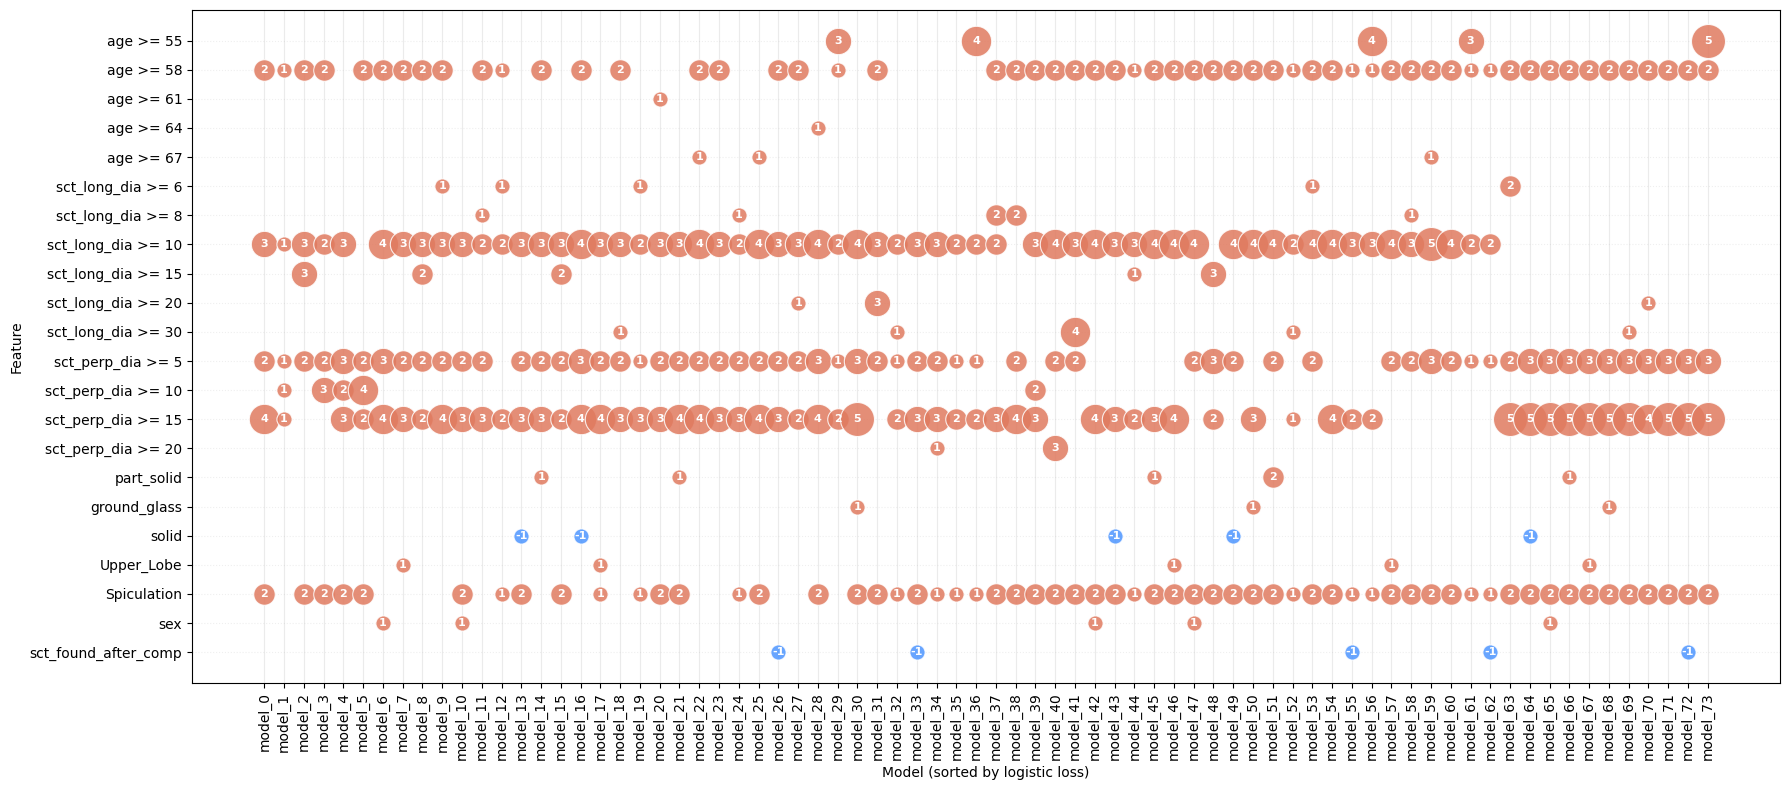

In [35]:
plot_feature_model_matrix(betas_int, X_train_STLMD_bin)

## Compared with Black Box Model

用test data来计算fasterrisk和其他black box model的ROC。这里我们选择EBM以及Random Forest以及XGBoost

In [36]:
def ensemble_predict_probs(X_test: np.ndarray, multipliers: np.ndarray, 
                           intercepts: np.ndarray, coef_matrix: np.ndarray) -> np.ndarray:
    """
    对每个样本，使用 FastRisk 模型中的所有模型计算概率，然后求平均。
    
    参数:
        X_test: 测试集特征矩阵 (n_samples, n_features)
        multipliers: 所有模型的乘数数组 (n_models,)
        intercepts: 所有模型的截距数组 (n_models,)
        coef_matrix: 所有模型的系数矩阵 (n_models, n_features)
    
    返回:
        ensemble_probs: 每个样本的平均预测概率 (n_samples,)
    """
    n_samples = X_test.shape[0]
    n_models = len(multipliers)
    
    # 累积每个样本的概率
    prob_matrix = np.zeros((n_samples, n_models))
    
    # 对每个模型计算概率
    for i in range(n_models):
        mult = float(multipliers[i])
        b0 = float(intercepts[i])
        betas = np.asarray(coef_matrix[i], dtype=int)
        
        # 计算该模型对所有样本的概率
        probs = model_probs(mult, b0, betas, X_test)
        prob_matrix[:, i] = probs
    
    # 对每个样本的概率求平均
    ensemble_probs = prob_matrix.mean(axis=1)
    
    return ensemble_probs

In [37]:
avg_probs_fasterrisk = ensemble_predict_probs(X_test_STLMD, multipliers, beta0_int, betas_int)
avg_train_probs_fasterrisk = ensemble_predict_probs(X_train_STLMD, multipliers, beta0_int, betas_int)

## 取最好的模型来进行预测

In [38]:
multipliers1 = multipliers[[0]]
beta0_int1 = beta0_int[[0]]
betas_int1 = betas_int[[0], :]
train_prob_fasterrisk = ensemble_predict_probs(X_train_STLMD, multipliers1, beta0_int1, betas_int1)
test_prob_fasterrisk = ensemble_predict_probs(X_test_STLMD, multipliers1, beta0_int1, betas_int1)

使用 X_train_STLMD_df 和 y_train_STLMD 来训练 black box model

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc as auc_score

# 将标签转换为 {0, 1} 格式（RandomForest 需要）
y_train_STLMD_01 = (y_train_STLMD + 1.0) / 2.0
y_test_STLMD_01 = (y_test_STLMD + 1.0) / 2.0

# 训练 Random Forest 模型
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest model...")
rf_model.fit(X_train_STLMD_df, y_train_STLMD_01)
print("Training completed!")

# 预测测试集的概率
rf_probs = rf_model.predict_proba(X_test_STLMD_df)[:, 1]
rf_train_probs = rf_model.predict_proba(X_train_STLMD_df)[:, 1]

Training Random Forest model...
Training completed!


接下来是XGBoost模型

In [40]:
import xgboost as xgb

# 训练 XGBoost 模型
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("Training XGBoost model...")
xgb_model.fit(X_train_STLMD_df, y_train_STLMD_01)
print("Training completed!")

# 预测测试集的概率
xgb_probs = xgb_model.predict_proba(X_test_STLMD_df)[:, 1]  # 获取 P(y=1) 的概率
xgb_train_probs = xgb_model.predict_proba(X_train_STLMD_df)[:, 1]

Training XGBoost model...
Training completed!


## PanCan

In [41]:
# coefficients of pancan
pancan_coef = {
    'age': 0.0286687,
    'gender': 0.6010727,
    'Family_History': 0.29611,
    'diagemph': 0.2953112,
    'sct_long_dia': -5.385484,
    'ground_glass': -0.1276173,
    'part_solid': 0.3769578,
    'Upper_Lobe': 0.6581383,
    'Spiculation': 0.7729335,
    'num_nodule': -0.0824156,
    'intercept': -6.78917
}

df1_pancan = train_df.copy()
df1_pancan['sct_long_dia'] = df1_pancan['sct_long_dia']-4
df1_pancan['age'] = df1_pancan['age']-62
df1_pancan['num_nodule'] = df1_pancan['num_nodule']-4
df1_pancan['sct_long_dia'] = (df1_pancan['sct_long_dia'] / 10) ** (-0.5) - 1.58113883
df1_pancan['gender'] = df1_pancan['gender'].map({'male': 0, 'female': 1}).astype(int)

df2_pancan = df2.copy()
df2_pancan['sct_long_dia'] = df2_pancan['sct_long_dia']-4
df2_pancan['age'] = df2_pancan['age']-62
df2_pancan['num_nodule'] = df2_pancan['num_nodule']-4
df2_pancan['sct_long_dia'] = (df2_pancan['sct_long_dia'] / 10) ** (-0.5) - 1.58113883
df2_pancan['gender'] = df2_pancan['gender'].map({'male': 0, 'female': 1}).astype(int)

def pancan_predict_proba(df: pd.DataFrame, coef: dict) -> np.ndarray:
    intercept = coef['intercept']
    X = df.reindex(columns=list(coef.keys())).copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0.0)
    linear_term = intercept + X.mul(pd.Series(coef), axis=1).sum(axis=1)
    return 1.0 / (1.0 + np.exp(-linear_term.to_numpy(dtype=float)))

train_pred_probs_pancan = pancan_predict_proba(df1_pancan, pancan_coef)
test_pred_probs_pancan = pancan_predict_proba(df2_pancan, pancan_coef)

## Test set ROC

Model Performance Comparison on Test Set
FasterRisk                | AUC: 0.7302 | Accuracy: 0.9645
Random Forest             | AUC: 0.6900 | Accuracy: 0.9636
PanCan                    | AUC: 0.7123 | Accuracy: 0.9635


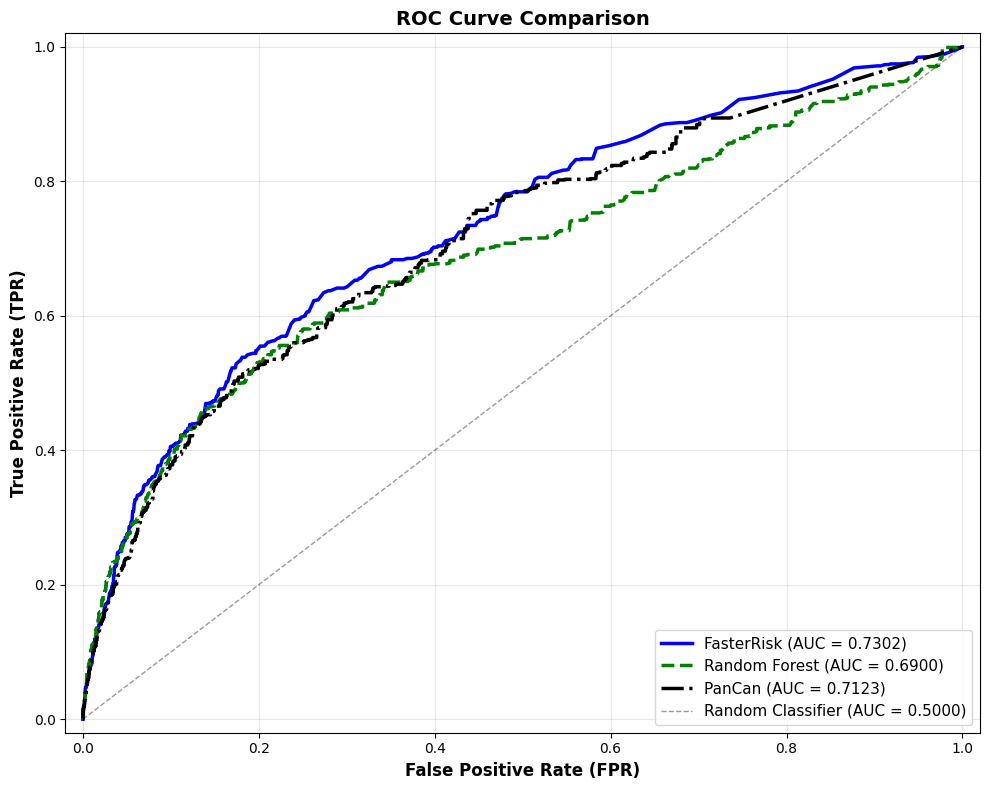

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))
y_test_true = df2["Cancer_lbl"]
y_train_true = y_train_STLMD_01.copy()

# 定义模型和对应的概率
models_data = [
    ("FasterRisk", avg_probs_fasterrisk, 'blue', '-', 2.5),
    ("Random Forest", rf_probs, 'green', '--', 2.5),
    # ("XGBoost", xgb_probs, 'red', '-.', 2.5),
    ("PanCan", test_pred_probs_pancan, 'black', '-.', 2.5),
]

# 计算并绘制每个模型的 ROC 曲线
print("=" * 70)
print("Model Performance Comparison on Test Set")
print("=" * 70)

for model_name, probs, color, linestyle, linewidth in models_data:
    # 计算 FPR, TPR 和 AUC
    fpr, tpr, _ = roc_curve(y_test_true, probs)
    auc_val = auc(fpr, tpr)
    
    # 绘制 ROC 曲线
    ax.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=linewidth,
            label=f'{model_name} (AUC = {auc_val:.4f})')
    
    # 打印性能指标
    acc = accuracy_score(y_test_true, (probs >= 0.5).astype(int))
    print(f"{model_name:25s} | AUC: {auc_val:.4f} | Accuracy: {acc:.4f}")

print("=" * 70)

# 绘制随机分类器的对角线
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random Classifier (AUC = 0.5000)')

# 设置图表格式
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()

fig.savefig(os.path.join(OUTDIR, "roc_comparison_testset.png"), dpi=300)

plt.show()

## Training set ROC

Model Performance Comparison on Training Set
FasterRisk                | AUC: 0.7354 | Accuracy: 0.9598
Random Forest             | AUC: 0.8993 | Accuracy: 0.9677
PanCan                    | AUC: 0.7217 | Accuracy: 0.9595


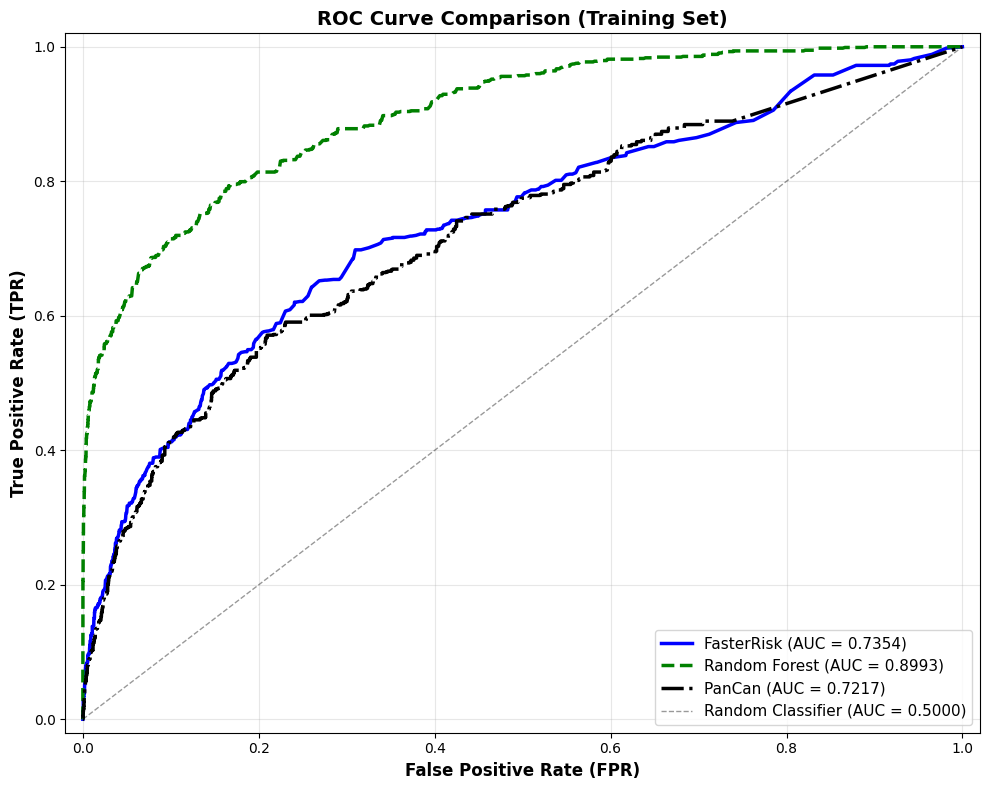

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))

# 定义模型和对应的概率
models_data = [
    ("FasterRisk", avg_train_probs_fasterrisk, 'blue', '-', 2.5),
    ("Random Forest", rf_train_probs, 'green', '--', 2.5),
    # ("XGBoost", xgb_train_probs, 'red', '-.', 2.5),
    ("PanCan", train_pred_probs_pancan, 'black', '-.', 2.5),
]

print("=" * 70)
print("Model Performance Comparison on Training Set")
print("=" * 70)

for model_name, probs, color, linestyle, linewidth in models_data:
    fpr, tpr, _ = roc_curve(y_train_true, probs)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=linewidth,
            label=f'{model_name} (AUC = {auc_val:.4f})')
    acc = accuracy_score(y_train_true, (probs >= 0.5).astype(int))
    print(f"{model_name:25s} | AUC: {auc_val:.4f} | Accuracy: {acc:.4f}")

print("=" * 70)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve Comparison (Training Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()

fig.savefig(os.path.join(OUTDIR, "roc_comparison_trainset.png"), dpi=300)

plt.show()


## Lung-RADS

In [44]:
def lungrads_predict(row) -> str:
    lungrads = "1"
    diameter = pd.to_numeric(row.get('sct_long_dia', np.nan), errors='coerce')
    if pd.isna(diameter):
        return lungrads

    nodule_type = 'unknown'
    if int(pd.to_numeric(row.get('solid', 0), errors='coerce') or 0) == 1:
        nodule_type = 'solid'
    elif int(pd.to_numeric(row.get('part_solid', 0), errors='coerce') or 0) == 1:
        nodule_type = 'part-solid'
    elif int(pd.to_numeric(row.get('ground_glass', 0), errors='coerce') or 0) == 1:
        nodule_type = 'ground-glass'

    solid_component = pd.to_numeric(row.get('sct_perp_dia', np.nan), errors='coerce')

    airway_text = str(
        row.get('airway_level', row.get('airway_location', row.get('sct_epi_loc', '')))
    ).lower()
    airway_nodule_flag = int(pd.to_numeric(row.get('airway_nodule', row.get('airway', 0)), errors='coerce') or 0) == 1
    airway_segmental_or_proximal = airway_nodule_flag and any(
        key in airway_text for key in ['segment', 'proximal', 'trachea', 'main', 'lobar']
    )

    thick_walled_cyst = int(pd.to_numeric(row.get('thick_walled_cyst', 0), errors='coerce') or 0) == 1
    multilocular_cyst = int(pd.to_numeric(row.get('multilocular_cyst', 0), errors='coerce') or 0) == 1

    if nodule_type == 'solid' and diameter >= 15:
        lungrads = "4B"
    elif nodule_type == 'part-solid' and (pd.notna(solid_component) and solid_component >= 8):
        lungrads = "4B"
    elif nodule_type == 'solid' and 8 <= diameter < 15:
        lungrads = "4A"
    elif nodule_type == 'part-solid' and diameter >= 6 and (pd.notna(solid_component) and 6 <= solid_component < 8):
        lungrads = "4A"
    elif airway_segmental_or_proximal:
        lungrads = "4A"
    elif thick_walled_cyst or multilocular_cyst:
        lungrads = "4A"
    elif nodule_type == 'solid' and 6 <= diameter < 8:
        lungrads = "3"
    elif nodule_type == 'part-solid' and diameter >= 6 and (pd.isna(solid_component) or solid_component < 6):
        lungrads = "3"
    elif nodule_type == 'ground-glass' and diameter >= 30:
        lungrads = "3"
    elif nodule_type == 'solid' and diameter < 6:
        lungrads = "2"
    elif nodule_type == 'part-solid' and diameter < 6:
        lungrads = "2"
    elif nodule_type == 'ground-glass' and diameter < 30:
        lungrads = "2"

    suspicious_margins = 'Spicul' in str(row.get('sct_margins', '')).lower()
    suspicious_spiculation = int(pd.to_numeric(row.get('Spiculation', 0), errors='coerce') or 0) == 1
    if lungrads in ['3', '4A', '4B'] and (suspicious_margins or suspicious_spiculation):
        lungrads = '4X'

    return lungrads

筛选solid和ground-glass，并且study_yr为0的training set 与 test set

In [ ]:
# -------------------------
# Load, normalize/encode
# -------------------------
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = df1[df1['Nodule_Type'] != 'part-solid']
df1 = df1[df1['study_yr'] == 0]
df2 = df2[df2['Nodule_Type'] != 'part-solid']
df2 = df2[df2['study_yr'] == 0]

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

df1['sct_ab_gwth'] = df1['sct_ab_gwth'].fillna(0)
df2['sct_ab_gwth'] = df2['sct_ab_gwth'].fillna(0)

df1 = df1.dropna(subset=['sct_perp_dia'])
df2 = df2.dropna(subset=['sct_perp_dia'])

# -------------------------
# Patient-level stratified split (on df1)
# -------------------------
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

# ============================================================
# STLMD (includes age & sex)  —  bins: age >= c, sct_long_dia >= c, sct_perp_dia >= c, sct_ab_gwth >= c
# ============================================================
X_train_STLMD_df, y_train_STLMD_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)
X_val_STLMD_df,   y_val_STLMD_raw   = prepare_data(val_df,   FEATURES_STLMD, LABEL_COL)
X_test_STLMD_df,  y_test_STLMD_raw  = prepare_data(df2,      FEATURES_STLMD, LABEL_COL)

X_train_STLMD_bin, X_val_STLMD_bin, X_test_STLMD_bin = binarize_and_align_custom(
    X_train_STLMD_df, X_val_STLMD_df, X_test_STLMD_df,
    feature_cuts={"age": CUTS_CONT["age"], "sct_long_dia": CUTS_CONT["sct_long_dia"], "sct_perp_dia": CUTS_CONT["sct_perp_dia"]}, #, "sct_ab_gwth": CUTS_CONT["sct_ab_gwth"]
    passthrough_binary=BIN_PASSTHROUGH_STLMD
)

y_train_STLMD = to_fastrisk_y(y_train_STLMD_raw, pos_label=1)
y_val_STLMD   = to_fastrisk_y(y_val_STLMD_raw,   pos_label=1)
y_test_STLMD  = to_fastrisk_y(y_test_STLMD_raw,  pos_label=1)

X_train_STLMD = X_train_STLMD_bin.to_numpy(dtype=float)
X_val_STLMD   = X_val_STLMD_bin.to_numpy(dtype=float)
X_test_STLMD  = X_test_STLMD_bin.to_numpy(dtype=float)

# 将标签转换为 {0, 1} 格式（RandomForest 需要）
y_train_STLMD_01 = (y_train_STLMD + 1.0) / 2.0
y_test_STLMD_01 = (y_test_STLMD + 1.0) / 2.0

# -------------------------
# Quick hygiene checks
# -------------------------
def _chk(Xtr, ytr, Xv, yv, Xte, yte, name):
    assert Xtr.shape[0] == ytr.shape[0] and Xv.shape[0] == yv.shape[0] and Xte.shape[0] == yte.shape[0], f"row mismatch in {name}"
    assert set(np.unique(ytr)) <= {-1.0, 1.0} and set(np.unique(yv)) <= {-1.0, 1.0} and set(np.unique(yte)) <= {-1.0, 1.0}, f"bad labels in {name}"
    print(f"{name:7s} -> X_train {Xtr.shape}, X_val {Xv.shape}, X_test {Xte.shape}")

_chk(X_train_STLMD, y_train_STLMD, X_val_STLMD, y_val_STLMD, X_test_STLMD, y_test_STLMD, "STLMD")

# Optional: feature names for each design
FEATURE_NAMES_STLMD  = list(X_train_STLMD_bin.columns)

KeyError: 'sct_ab_gwth'

In [ ]:
# ---------------------------------------------
# Wire up your prepared splits & feature names
# (These are defined in your dataset block.)
# ---------------------------------------------
SPLITS = {
    "STLMD": (X_train_STLMD, y_train_STLMD, X_val_STLMD, y_val_STLMD, X_test_STLMD, y_test_STLMD, FEATURE_NAMES_STLMD),
}

for name in DESIGNS_TO_RUN:
    print(f"\n=== Processing: {name} ===")
    (X_train, y_train, X_val, y_val, X_test, y_test, feature_names) = SPLITS[name]

    # build optimizer with Rashomon controls
    opt = make_optimizer(
        X=X_train, y=y_train,
        k=SPARSITY_K, parent_size=PARENT_SIZE,
        gap_tolerance=GAP_TOLERANCE,
        select_top_m=SELECT_TOP_M,
        max_attempts=MAX_ATTEMPTS,
        want_intercept=True
    )
    print(f"[opt] gap_tolerance={GAP_TOLERANCE}, select_top_m={SELECT_TOP_M}, maxAttempts={MAX_ATTEMPTS}, k={SPARSITY_K}, parent_size={PARENT_SIZE}")

    t0 = time.time()
    opt.optimize()
    print("Optimization takes {:.2f} seconds.".format(time.time() - t0))
    
    # Extract the trained models
    multipliers, beta0_int, betas_int = extract_models(opt.get_models())
    print("We generate {} risk score models from the sparse diverse pool".format(len(multipliers)))

    # metrics + probs (TRAIN / TEST)
    train_aucs, train_accs, n_terms, train_probs = compute_model_metrics(
        multipliers, beta0_int, betas_int, X_train, y_train
    )
    test_aucs,  test_accs,  _,        test_probs  = compute_model_metrics(
        multipliers, beta0_int, betas_int, X_test,  y_test
    )

    # save metrics CSV
    card_labels = [f"{i+1:02d}" for i in range(len(multipliers))]
    df_models = pd.DataFrame({
        "card": card_labels,
        "n_terms": n_terms,
        "train_auc": train_aucs,
        "test_auc":  test_aucs,
        "train_acc": train_accs,
        "test_acc":  test_accs,
        "intercept": beta0_int,
        "multiplier": multipliers,
    })
    csv_out = os.path.join(OUTDIR, f"model_metrics_{name}.csv")
    df_models.sort_values("test_auc", ascending=False).to_csv(csv_out, index=False)
    print(f"[AUC] Wrote {csv_out}")

    # ROC subplots for ALL models (TRAIN & TEST), 50 per page
    y_train01 = ((y_train + 1.0) / 2.0).astype(int)
    y_test01  = ((y_test  + 1.0) / 2.0).astype(int)


=== Processing: STLMD ===
[opt] gap_tolerance=0.15, select_top_m=100, maxAttempts=200, k=5, parent_size=50
Optimization takes 25.14 seconds.
We generate 65 risk score models from the sparse diverse pool
[AUC] Wrote ./image/fasterrisk2/model_metrics_STLMD.csv


In [ ]:
lungrads_test_array = X_test_STLMD_df.apply(lungrads_predict, axis=1).to_numpy()

In [ ]:
multipliers1 = multipliers[[0]]
beta0_int1 = beta0_int[[0]]
betas_int1 = betas_int[[0], :]
test_prob_fasterrisk = ensemble_predict_probs(X_test_STLMD, multipliers, beta0_int, betas_int)

In [ ]:
n1 = np.asarray(test_prob_fasterrisk).reshape(-1)
n2 = np.asarray(lungrads_test_array).reshape(-1)
n3 = np.asarray(y_test_STLMD_01).reshape(-1)

test_merge_df = pd.DataFrame({
    'test_prob_fasterrisk': n1,
    'lungrads_test_array': n2,
    'y_test_STLMD_01': n3
})

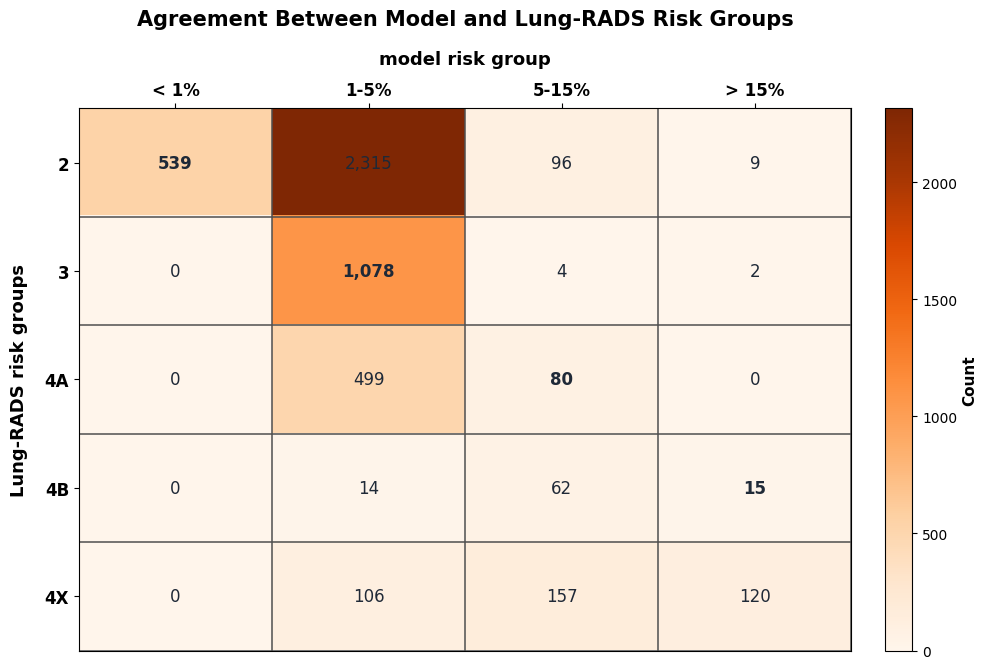

In [ ]:
def build_pseudo_confusion_matrix(test_prob_fasterrisk, lungrads_test_array, save_path=None):
    probs = pd.Series(np.asarray(test_prob_fasterrisk).reshape(-1), name='test_prob_fasterrisk')
    lungrads = pd.Series(np.asarray(lungrads_test_array).reshape(-1), name='lungrads_test_array').astype(str)

    if len(probs) != len(lungrads):
        raise ValueError('test_prob_fasterrisk 和 lungrads_test_array 长度不一致')

    bins = pd.Series(index=probs.index, dtype='object')
    bins[probs < 0.01] = '< 1%'
    bins[(probs >= 0.01) & (probs < 0.05)] = '1-5%'
    bins[(probs >= 0.05) & (probs <= 0.15)] = '5-15%'
    bins[probs > 0.15] = '> 15%'

    valid = bins.notna()

    row_order = ['2', '3', '4A', '4B', '4X']
    existing_rows = [r for r in row_order if r in set(lungrads[valid])]
    extra_rows = sorted(set(lungrads[valid]) - set(existing_rows))
    final_rows = existing_rows + extra_rows

    col_order = ['< 1%', '1-5%', '5-15%', '> 15%']

    cm = pd.crosstab(
        lungrads[valid],
        bins[valid],
        rownames=['lungrads_test_array'],
        colnames=['test_prob_fasterrisk'],
        dropna=False,
    ).reindex(index=final_rows, columns=col_order, fill_value=0)

    r, c = cm.shape

    cmap = plt.cm.Oranges.copy()

    fig, ax = plt.subplots(figsize=(10, 6.8))
    ax.imshow(cm.to_numpy(dtype=float), cmap=cmap, aspect='auto')

    ax.set_xticks(np.arange(c))
    ax.set_yticks(np.arange(r))
    ax.set_xticklabels(col_order, fontsize=12, fontweight='bold')
    ax.set_yticklabels(final_rows, fontsize=12, fontweight='bold')

    ax.set_xticks(np.arange(-0.5, c, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, r, 1), minor=True)
    ax.grid(which='minor', color='#4f4f4f', linestyle='-', linewidth=1.1)
    ax.tick_params(which='minor', bottom=False, left=False)

    ax.xaxis.set_label_position('top')
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_xlabel('model risk group', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_ylabel('Lung-RADS risk groups', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_title('Agreement Between Model and Lung-RADS Risk Groups', fontsize=15, fontweight='bold', pad=18)

    diag_map = {'2': '< 1%', '3': '1-5%', '4A': '5-15%', '4B': '> 15%'}
    for i in range(r):
        for j in range(c):
            v = int(cm.iloc[i, j])
            is_diag = final_rows[i] in diag_map and diag_map[final_rows[i]] == col_order[j]
            ax.text(
                j,
                i,
                f'{v:,}',
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold' if is_diag else 'normal',
                color='#1f2937'
            )

    cbar = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Count', fontsize=11, fontweight='bold')

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return cm


pseudo_cm = build_pseudo_confusion_matrix(
    test_prob_fasterrisk,
    lungrads_test_array,
    save_path=os.path.join(OUTDIR, 'pseudo_confusion_matrix.png')
)